# Customer Churn Risk Analysis
## Business Problem
A telecom company is losing customers.
Need to find who is churning, why,
and how much revenue is at risk.

In [7]:
#Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [8]:
#Load Dataset

df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn[1].csv")

print("Shape:\n", df.shape)
print("\nFirst Five Rows:\n", df.head())
print("\nColumn Info:\n", df.info())
print("\nDescribe Data:\n", df.describe())
print("\ncolumns to list\n", df.columns.tolist())
print("\nMissing Values:\n", df.isnull().sum())

Shape:
 (7043, 21)

First Five Rows:
    customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingT

In [9]:
#Data Cleaning
#TotalCharges is stored in wrong data type
#This is mainly because of missing vales is stored as " "
#Pandas read it as text
#lets fix the missing values

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors="coerce") #Converting to numeric
df['TotalCharges'] = df['TotalCharges'].fillna(df["TotalCharges"].mean())

print(df['TotalCharges'].isna().sum())

0


In [10]:
#Churn Rate
churn_rate = df['Churn'].value_counts(normalize = True)*100

#Revenue at Risk
churned = df[df['Churn'] == 'Yes']
revenue_at_risk = churned['MonthlyCharges'].sum() * 12

print(f"Total Customers: {len(df):,}")
print(f"Churned Customers: {churned.shape[0]:,}")
print(f"Churn Rate: {churn_rate['Yes']:.1f}")
print(f"Annual Revenue at Risk: ${revenue_at_risk:,.0f}")

Total Customers: 7,043
Churned Customers: 1,869
Churn Rate: 26.5
Annual Revenue at Risk: $1,669,570


In [11]:
print(df.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [12]:
#Checking if contract is causing the Churn

#churn is in text have to convert it to numeric to get percentages
df['churn_numeric'] = df['Churn'].map({'Yes':1, 'No':0})

#now checking if contract is causing churn
contract_churn = df.groupby('Contract')['churn_numeric'].mean() * 100

#Print the churn percentage caused by contract
print(contract_churn)

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: churn_numeric, dtype: float64


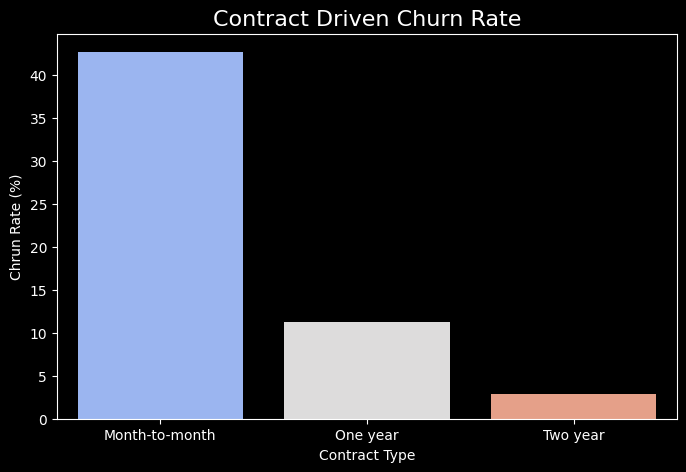

In [13]:
# Visualisation
plt.style.use('dark_background')
plt.figure(figsize=(8,5))
sns.barplot(x=contract_churn.index,
            y = contract_churn.values,
            hue = contract_churn.index,
            palette = "coolwarm",
            legend = False)
plt.title("Contract Driven Churn Rate", fontsize = 16)
plt.xlabel("Contract Type")
plt.ylabel("Chrun Rate (%)")
plt.show()

In [14]:
# Check if partner causing the churn rate
partner_churn = df.groupby('Partner')['churn_numeric'].mean() * 100

print(partner_churn)

Partner
No     32.957979
Yes    19.664903
Name: churn_numeric, dtype: float64


In [15]:
#checking if senior citizens casuing churn rate
seniorcitizens_churn = df.groupby('SeniorCitizen')['churn_numeric'].mean() * 100
print(seniorcitizens_churn)

SeniorCitizen
0    23.606168
1    41.681261
Name: churn_numeric, dtype: float64


In [16]:
#checking if techsupport is causing the churn
techsupport_churn = df.groupby('TechSupport')['churn_numeric'].mean() * 100
print(techsupport_churn)

TechSupport
No                     41.635474
No internet service     7.404980
Yes                    15.166341
Name: churn_numeric, dtype: float64


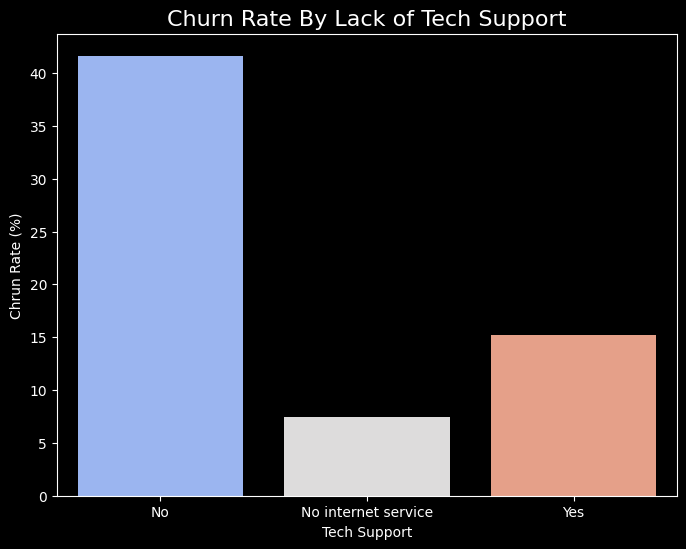

In [17]:
# Visualization

plt.figure(figsize=(8,6))
sns.barplot(x = techsupport_churn.index,
            y = techsupport_churn.values,
            hue = techsupport_churn.index,
            palette = "coolwarm")
plt.title("Churn Rate By Lack of Tech Support", fontsize = 16)
plt.xlabel("Tech Support")
plt.ylabel("Chrun Rate (%)")
plt.show()


In [18]:
#Checking if lack of tech and month-to-month is main cause
tech_and_contract = df[(df['TechSupport'] == 'No') & (df['Contract'] == 'Month-to-month')]
high_risk_rate = tech_and_contract['churn_numeric'].mean() * 100
high_risk_count = len(tech_and_contract)
high_risk_revenue = tech_and_contract[tech_and_contract['Churn'] == 'Yes']['MonthlyCharges'].sum() * 12

print(f"High Risk Rate: {high_risk_rate:.1f}%")
print(f"High Risk Count: {high_risk_count:,}")
print(f"High Risk Annual Revenue: ${high_risk_revenue:,.0f}")


High Risk Rate: 50.4%
High Risk Count: 2,680
High Risk Annual Revenue: $1,228,587


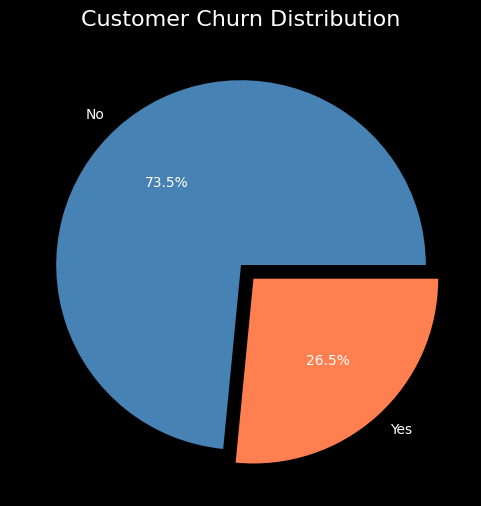

In [19]:
# Visualisation

plt.figure(figsize=(6,6))
df['Churn'].value_counts().plot(
    kind = "pie",
    autopct = "%1.1f%%",
    colors = ['steelblue', 'coral'],
    explode = [0, 0.1]
)

plt.title("Customer Churn Distribution", fontsize = 16)
plt.ylabel('')
plt.show()

In [20]:
#Calculating the Risk Score

df['risk_score'] = 0
df.loc[df['Contract'] == 'Month-to-month', 'risk_score'] += 40
df.loc[df['TechSupport'] == 'No', 'risk_score'] += 30
df.loc[df['SeniorCitizen'] == 1, 'risk_score'] += 20
df.loc[df['Partner'] == 'No', 'risk_score'] += 10

print(df['risk_score'].value_counts().sort_index())

risk_score
0      1370
10      802
20      133
30      495
40      596
50      820
60       92
70      729
80     1308
90      292
100     406
Name: count, dtype: int64


In [21]:
#Categorising the Risk Score
df['risk_category'] = df['risk_score'].apply(
    lambda x: 'High' if x >= 70
    else 'Medium' if x >= 40
    else 'Low'
)

#Counting Each Category
print("Risk Category Count\n", df['risk_category'].value_counts())

#Churn Rate per category
print("\nRisk Rate Per Category\n", df.groupby('risk_category')['churn_numeric'].mean() * 100)


Risk Category Count
 risk_category
Low       2800
High      2735
Medium    1508
Name: count, dtype: int64

Risk Rate Per Category
 risk_category
High      50.091408
Low        6.142857
Medium    21.684350
Name: churn_numeric, dtype: float64


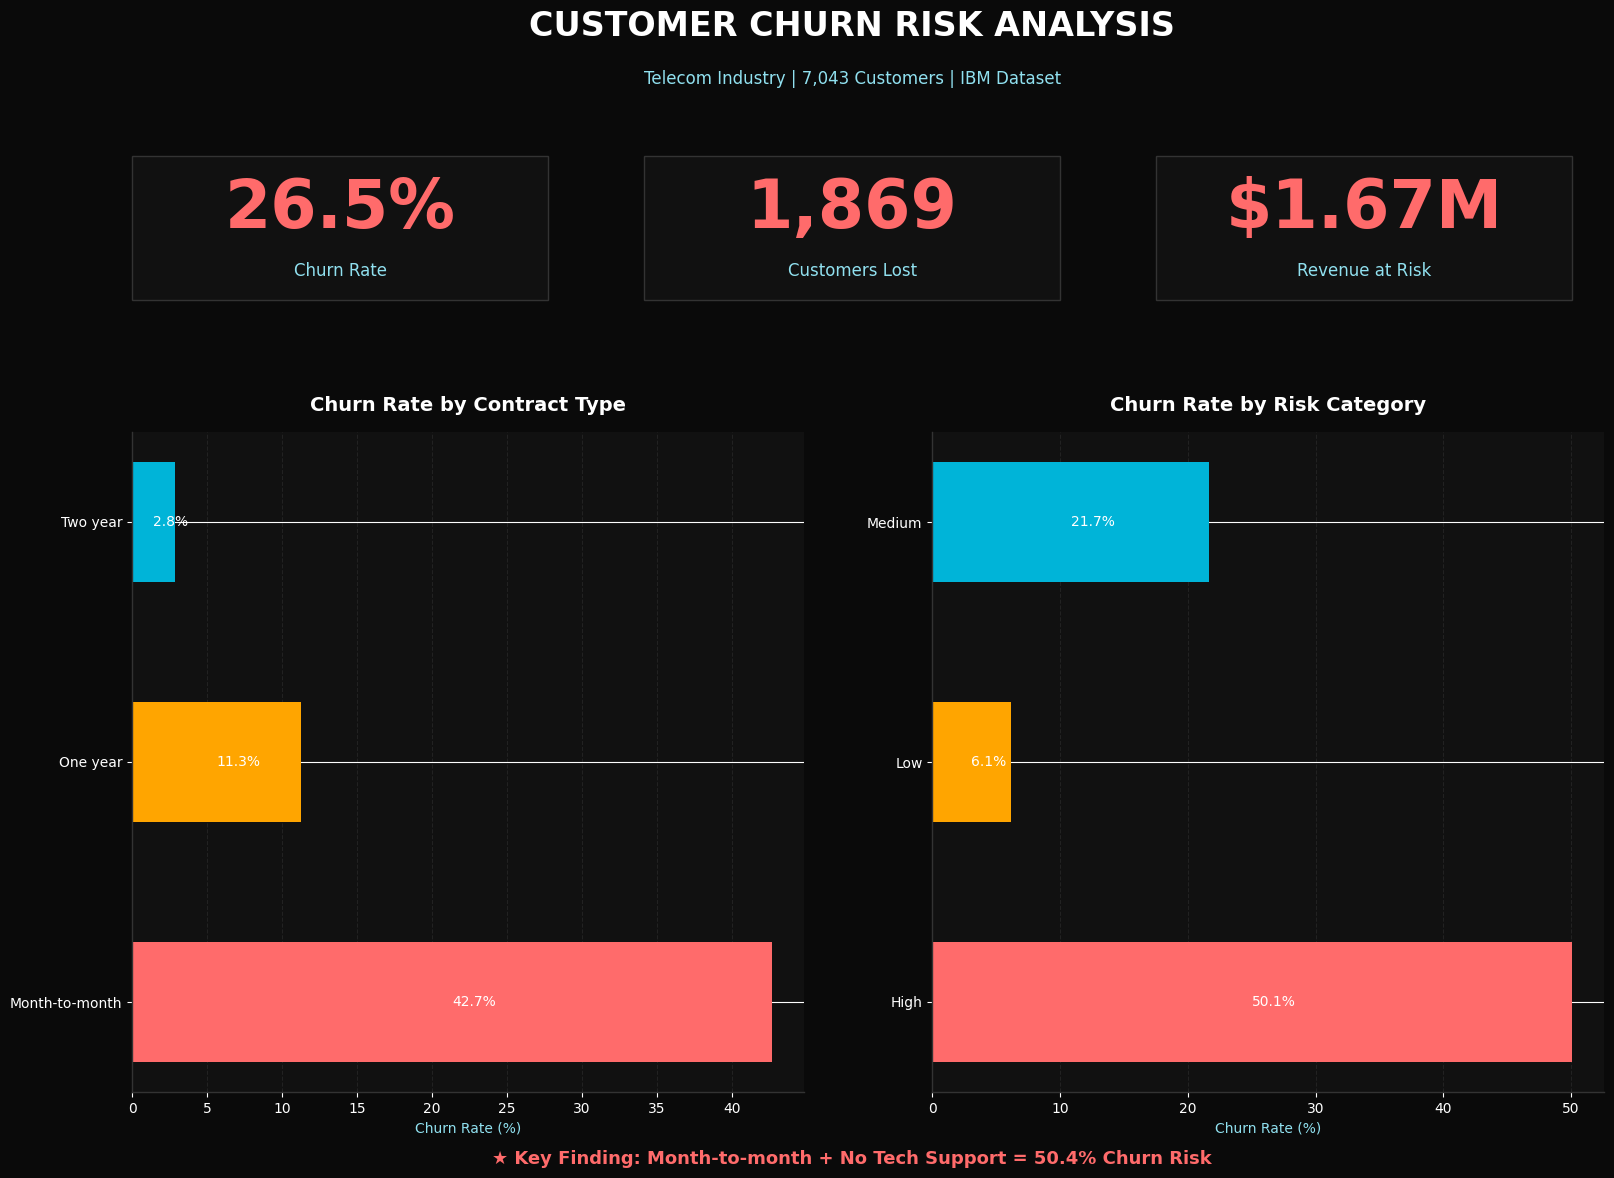

In [53]:
#Final Dashboard

plt.style.use('dark_background')

fig = plt.figure(figsize = (16,12))
fig.patch.set_facecolor('#0A0A0A')


#Main title
fig.text(0.5, 0.96,
         'CUSTOMER CHURN RISK ANALYSIS',
         fontsize = 24,
         fontweight = 'bold',
         color = 'white',
         ha = 'center')

#subtitle
fig.text(0.5, 0.92,
         'Telecom Industry | 7,043 Customers | IBM Dataset',
         fontsize = 12,
         color = '#90E0EF',
         ha = 'center')

#===========================
#KPI Section - 3 Big Numbers
#===========================

#Box Background for KPIs
for x in [0.18, 0.50, 0.82]:
  fig.add_artist(plt.Rectangle((x-0.13, 0.74), 0.26, 0.12,
                               transform = fig.transFigure,
                               facecolor = '#111111',
                               edgecolor = '#333333',
                               linewidth = 1))

#========================
# KPI 1 - Churn Rate
#========================
fig.text(0.18, 0.80, "26.5%",
           fontsize = 48, fontweight = 'bold',
           color = '#FF6B6B', ha = 'center')
fig.text(0.18, 0.76, 'Churn Rate',
           fontsize = 12, color = '#90E0EF', ha = 'center')

#=========================
# KPI 2 - Lost Customers
#=========================
fig.text(0.50, 0.80, "1,869",
           fontsize = 48, fontweight = 'bold',
           color = '#FF6B6B', ha = 'center')
fig.text(0.50, 0.76, 'Customers Lost',
           fontsize = 12, color = '#90E0EF', ha = 'center')

#=========================
#KPI 3 - Revenue at Risk
#=========================
fig.text(0.82,0.80, '$1.67M',
           fontsize = 48, fontweight = 'bold',
           color = '#FF6B6B', ha = 'center')
fig.text(0.82, 0.76, 'Revenue at Risk',
           fontsize = 12, color = '#90E0EF', ha = 'center')

#==============================
# Left Chart - Contract Churn
#==============================
ax1 = fig.add_axes([0.05, 0.08, 0.42, 0.55])
ax1.set_facecolor('#111111')

colors_contract = ['#FF6B6B', '#FFA500', '#00B4D8']
bars = ax1.barh(contract_churn.index,
                contract_churn.values,
                color = colors_contract,
                edgecolor = 'none',
                height = 0.5)

ax1.set_title('Churn Rate by Contract Type',
              color = 'white', fontsize = 14,
              fontweight = 'bold', pad = 15)
ax1.set_xlabel('Churn Rate (%)',
               color = '#90E0EF',fontsize = 10)
ax1.tick_params(colors = 'White')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_color('#333333')
ax1.spines['left'].set_color('#333333')
ax1.xaxis.grid(True, color = '#333333',
               linestyle = '--', alpha = 0.5)

for bar, val in zip(bars, contract_churn.values):
  ax1.text(val / 2,
           bar.get_y() + bar.get_height()/2,
           f'{val:.1f}%',
           va = 'center', color = 'white', fontsize = 10)

#==============================
# Right Chart - Risk Category
#==============================
ax2 = fig.add_axes([0.55, 0.08, 0.42, 0.55])
ax2.set_facecolor('#111111')

risk_churn = df.groupby('risk_category')['churn_numeric'].mean() * 100
color_risk = ['#FF6B6B', '#FFA500', '#00B4D8']
bars2 = ax2.barh(risk_churn.index,
                 risk_churn.values,
                 color = color_risk,
                 edgecolor = 'none',
                 height = 0.5)

ax2.set_title('Churn Rate by Risk Category',
              color = 'white', fontsize = 14, fontweight = 'bold', pad = 15)
ax2.set_xlabel('Churn Rate (%)',
               color='#90E0EF', fontsize=10)
ax2.tick_params(colors='white')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['bottom'].set_color('#333333')
ax2.spines['left'].set_color('#333333')
ax2.xaxis.grid(True, color='#333333',
               linestyle='--', alpha=0.5)


for bar, val in zip(bars2, risk_churn.values):
    ax2.text(val / 2,
             bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%',
             va='center', color='white', fontsize=10)

#===========================
# Bottom Insight
#===========================
fig.text(0.5, 0.02,
         '★ Key Finding: Month-to-month + No Tech Support = 50.4% Churn Risk',
         ha='center', fontsize=13,
         color='#FF6B6B', fontweight='bold')


plt.savefig('Churn_dashboard.png',
            dpi = 150,
            bbox_inches = 'tight',
            facecolor = '#0A0A0A')
plt.show()



## Business Recommendations

### Finding 1: Contract Type is the #1 Churn Driver
- Month-to-month customers churn at 42.7%
- Two-year customers churn at only 2.8%
- RECOMMENDATION: Offer 20% discount to convert
  month-to-month customers to annual contracts
- Expected Impact: Reducing month-to-month churn
  by 50% would retain ~400 customers worth $480K





### Finding 2: Lack of Tech Support Drives Churn
- Customers without tech support churn at 41.6%
- Customers with tech support churn at only 15.2%
- RECOMMENDATION: Offer free 3-month tech support
  trial to all high-risk customers
- Expected Impact: Could reduce churn rate by 15-20%

### Finding 3: 2,735 High-Risk Customers Need Attention
- These customers have 50.1% churn probability
- They represent majority of 1.67M dollars revenue at risk
- RECOMMENDATION: Retention team should call these
  customers this week with special offers
- Expected Impact: Retaining 30% would save ~$500K